Intrduction:
It is a non - parametric based learning algo. that predicts the (Classification) or (Regression) of a new data point based in the majority ( or Average) of it's K most similar neighbour data points.

K is a hyperparameter which we give to the algo. If the K is 5 then during prediction our model searches K number of elements which are nearest of our given data point. 

Example: If K = 5, then during training our model searches for 5 nearest data points. For classification it will se whoose number of data points are more like: 3 blue 2 red then it says our given data point lies in blue class. For regression this will take the mean of the data points.

We use "Euclidian Distance" : whole under root{(x1 of a - x1 of b)^2 + (x2 of a - x2 of b)^2}

How to decide the value of K: Heuristic (Jugaad approach) -> under root of{n} where n is number of observations

Real approach : try different values of K, then cross validate the model. Choose the value which gives the best performence (samllest loss)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
df = pd.read_csv('knn_customer_dataset_240_rows.csv')
df.head()

,Customer_ID,Age,Annual_Spending_k,target
0,C025,41,67.9,High Value
1,C007,38,58.0,Low Value
2,C094,58,62.0,High Value
3,C110,54,92.8,High Value
4,C105,56,63.1,Low Value


In [10]:
target_column = "target"

X = df.drop(columns=[target_column])
y = df[target_column]

X.head()

,Customer_ID,Age,Annual_Spending_k
0,C025,41,67.9
1,C007,38,58.0
2,C094,58,62.0
3,C110,54,92.8
4,C105,56,63.1


In [11]:
X = X.select_dtypes(include=np.number)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
     

Training data: (192, 2)
Testing data: (48, 2)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
     

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
y_pred = knn.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.9166666666666666


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  High Value       0.88      0.96      0.92        23
   Low Value       0.96      0.88      0.92        25

    accuracy                           0.92        48
   macro avg       0.92      0.92      0.92        48
weighted avg       0.92      0.92      0.92        48



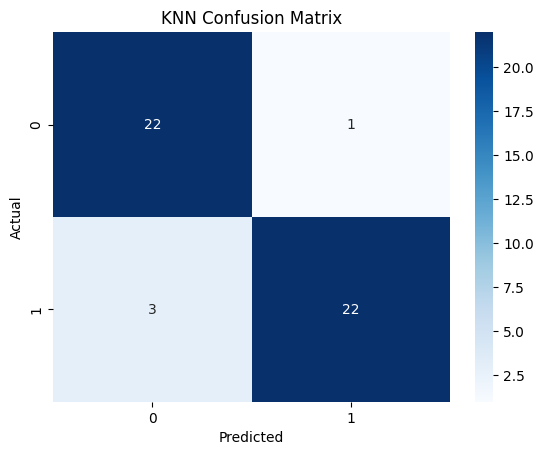

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

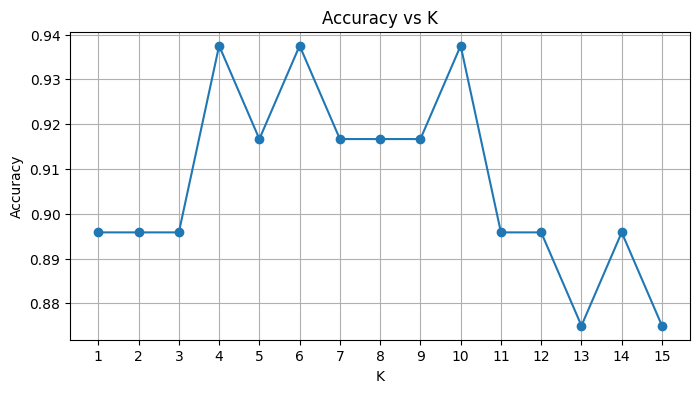

In [17]:
k_values = range(1, 16)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracy_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [18]:
param_grid = {
    "n_neighbors": range(1, 16),
    "weights": ["uniform", "distance"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'n_neighbors': 7, 'weights': 'uniform'}
Best CV Accuracy: 0.9375168690958164


In [19]:
best_knn = grid.best_estimator_
final_pred = best_knn.predict(X_test_scaled)

print('Final Test Accuracy:', accuracy_score(y_test, final_pred))
print()
print(classification_report(y_test, final_pred))

Final Test Accuracy: 0.9166666666666666

              precision    recall  f1-score   support

  High Value       0.88      0.96      0.92        23
   Low Value       0.96      0.88      0.92        25

    accuracy                           0.92        48
   macro avg       0.92      0.92      0.92        48
weighted avg       0.92      0.92      0.92        48



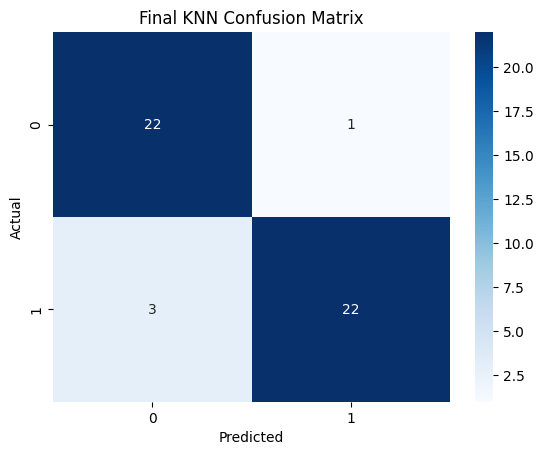

In [20]:
final_cm = confusion_matrix(y_test, final_pred)

sns.heatmap(final_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final KNN Confusion Matrix")
plt.show()

In [21]:
new_data = pd.DataFrame([[0, 0]], columns=X.columns)

new_data_scaled = scaler.transform(new_data)
prediction = best_knn.predict(new_data_scaled)

print("Predicted Class:", prediction[0])

Predicted Class: Low Value
